## Import Libraries

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score


# Read CSV File

In [51]:
df = pd.read_csv("../data/raw/Credit_Card_Applications.csv")

## Separate features and target

In [52]:
X = df.drop(columns=["CustomerID", "Class"])
y = df["Class"]

# Train-Test Split

Split the dataset into training and testing sets.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

Standardize the numerical features to improve model performance.

In [54]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

Train the machine learning model using the training data.

In [55]:
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Model Prediction

Predict the target labels for the test dataset.

In [56]:
y_pred = model.predict(X_test)

# Model Evaluation

Evaluate the model using different classification metrics.

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


# Confusion Matrix

Visualize the classification results using a confusion matrix.

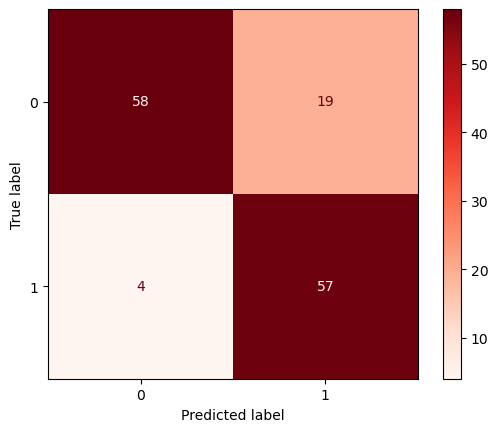

In [58]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Reds"
)

plt.show()

# Classification Report

Display precision, recall, F1-score, and support.

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.75      0.83        77
           1       0.75      0.93      0.83        61

    accuracy                           0.83       138
   macro avg       0.84      0.84      0.83       138
weighted avg       0.85      0.83      0.83       138



# ROC Curve

Evaluate the classifier using the ROC curve and AUC score.

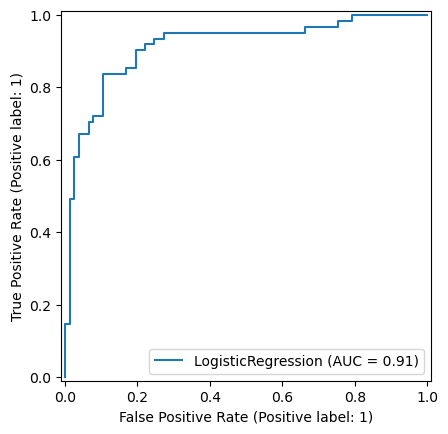

In [60]:
RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.show()

# AUC Score

Calculate the Area Under the ROC Curve.

In [61]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.9139876516925697
